In [ ]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
# ============================================
# STEP 2: LOAD DATASET
# ============================================

data = pd.read_csv("Mall_Customers.csv")
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
# ============================================
# STEP 3: SELECT FEATURES
# ============================================

# Use important features
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [ ]:
# ============================================
# STEP 4: FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

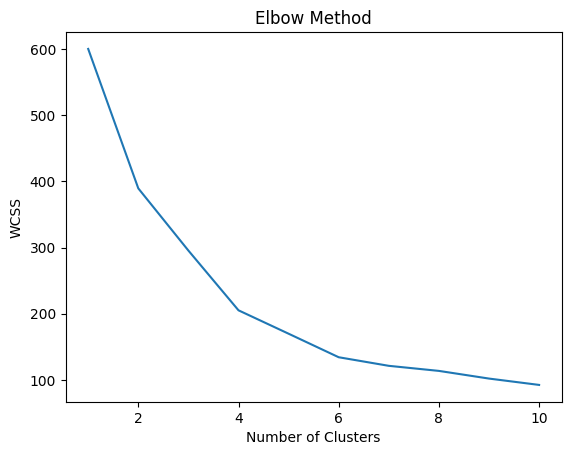

In [ ]:
# ============================================
# STEP 5: FIND OPTIMAL K (ELBOW METHOD)
# ============================================

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
# ============================================
# STEP 6: APPLY K-MEANS
# ============================================

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

In [ ]:
# ============================================
# STEP 7: EVALUATION
# ============================================

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.40846873777345605


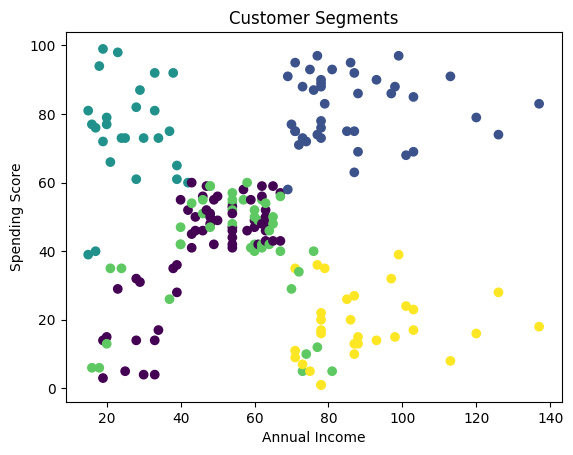

In [ ]:
# ============================================
# STEP 8: VISUALIZATION
# ============================================

plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'],
            c=data['Cluster'])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()